Data Cleansing and Transformation for Machine Learning

Data Loading and Initial Assessment

Data preparation begins with loading and assessing the raw data to understand its structure, identify potential issues, and plan the necessary cleaning steps. This fundamental process establishes the foundation for all subsequent data preprocessing tasks in machine learning workflows.

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer

# Load sample dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Initial assessment
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
print("\nBasic Statistics:\n", df.describe())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Output sample
"""
Dataset Shape: (569, 30)
Missing Values: 
mean radius                0
mean texture               0
mean perimeter            0
...
Data Types:
mean radius      float64
mean texture     float64
...
"""

Dataset Shape: (569, 30)

Missing Values:
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

Data Types:
 mean radius                float64
mean texture             

'\nDataset Shape: (569, 30)\nMissing Values: \nmean radius                0\nmean texture               0\nmean perimeter            0\n...\nData Types:\nmean radius      float64\nmean texture     float64\n...\n'

 Missing Value Detection and Visualization

Understanding the patterns of missing values is crucial for deciding on appropriate imputation strategies. Visualization helps identify potential relationships between missing values and assists in making informed decisions about handling them.


Missing Value Summary:
                                           Column  Missing Percentage
mean radius                          mean radius            8.260105
mean texture                        mean texture            8.260105
mean compactness                mean compactness            8.260105
mean smoothness                  mean smoothness            8.260105
mean symmetry                      mean symmetry            8.260105
mean concavity                    mean concavity            8.260105
perimeter error                  perimeter error            8.260105
texture error                      texture error            8.260105
mean fractal dimension    mean fractal dimension            8.260105
radius error                        radius error            8.260105
area error                            area error            8.260105
concave points error        concave points error            8.260105
compactness error              compactness error            8.260105
smoothnes

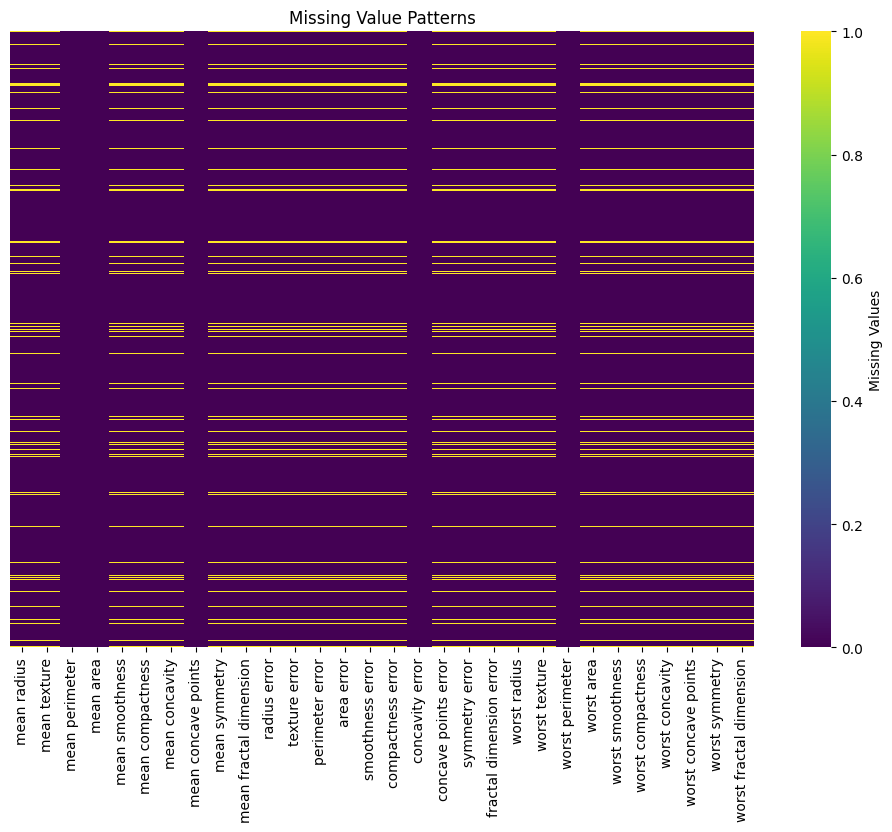

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_missing_values(df):
    # Create missing value matrix
    missing_matrix = df.isnull()
    
    # Plot heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(missing_matrix, 
                yticklabels=False,
                cmap='viridis',
                cbar_kws={'label': 'Missing Values'})
    plt.title('Missing Value Patterns')
    
    # Calculate missing percentages
    missing_percentages = (df.isnull().sum() / len(df)) * 100
    missing_info = pd.DataFrame({
        'Column': df.columns,
        'Missing Percentage': missing_percentages
    }).sort_values('Missing Percentage', ascending=False)
    
    return missing_info

# Example usage with synthetic missing values
df_with_missing = df.copy()
df_with_missing.iloc[np.random.randint(0, len(df), 50), 
                    np.random.randint(0, df.shape[1], 50)] = np.nan

missing_info = visualize_missing_values(df_with_missing)
print("\nMissing Value Summary:\n", missing_info)

Advanced Missing Value Imputation

Traditional imputation methods like mean or median replacement can be inadequate for complex datasets. This implementation demonstrates sophisticated imputation techniques using iterative imputation, which considers the relationships between features.

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

def advanced_imputation(df):
    """
    Perform advanced imputation using IterativeImputer with Random Forest
    
    Parameters:
    df: DataFrame with missing values
    
    Returns:
    df_imputed: DataFrame with imputed values
    quality_metrics: Dictionary with imputation quality information
    """
    
    # Initialize iterative imputer with random forest estimator
    imputer = IterativeImputer(
        estimator=RandomForestRegressor(n_estimators=100, random_state=42),
        max_iter=10,
        random_state=42,
        initial_strategy='mean',  # Strategy for initial imputation
        imputation_order='ascending',  # Order of imputation
        skip_complete=True,  # Skip features with no missing values
        min_value=None,  # Minimum possible imputed value
        max_value=None,  # Maximum possible imputed value
        verbose=1  # Show progress
    )
    
    # Perform imputation
    print("Starting iterative imputation...")
    imputed_data = imputer.fit_transform(df)
    print(f"Imputation completed after {imputer.n_iter_} iterations")
    
    # Create new dataframe with imputed values
    df_imputed = pd.DataFrame(
        imputed_data, 
        columns=df.columns, 
        index=df.index
    )
    
    # Calculate imputation quality metrics
    quality_metrics = {
        'n_iterations': imputer.n_iter_,  # Number of iterations performed
        'initial_strategy': imputer.initial_strategy_,
        'imputation_order': imputer.imputation_order_,
        'features_with_missing': list(df.columns[df.isnull().any()].values),
        'missing_count_before': df.isnull().sum().to_dict(),
        'missing_count_after': df_imputed.isnull().sum().to_dict(),
        'converged': imputer.n_iter_ < imputer.max_iter  # Whether converged early
    }
    
    # Note: Individual feature importances are not directly available
    # because multiple estimators are used across iterations
    
    return df_imputed, quality_metrics

# Create sample data with missing values
def create_sample_data(n_samples=100, n_features=5, missing_rate=0.1):
    """Create sample data with missing values for testing"""
    np.random.seed(42)
    
    # Create correlated data
    X = np.random.randn(n_samples, n_features)
    
    # Add correlations
    for i in range(1, n_features):
        X[:, i] = X[:, i] + X[:, 0] * 0.5
    
    # Create DataFrame
    df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(n_features)])
    
    # Introduce missing values randomly
    mask = np.random.random(df.shape) < missing_rate
    df[mask] = np.nan
    
    return df

# Create sample data
print("Creating sample data with missing values...")
df_with_missing = create_sample_data(n_samples=200, n_features=5, missing_rate=0.15)
print(f"Original data shape: {df_with_missing.shape}")
print(f"Missing values per column:\n{df_with_missing.isnull().sum()}")
print()

# Run imputation
df_imputed, quality_metrics = advanced_imputation(df_with_missing)

print("\n" + "="*60)
print("IMPUTATION RESULTS")
print("="*60)
print("\nQuality Metrics:")
for key, value in quality_metrics.items():
    print(f"  {key}: {value}")

# Compare original vs imputed
print("\n" + "="*60)
print("DATA COMPARISON")
print("="*60)
print("\nOriginal data (first 5 rows):")
print(df_with_missing.head())
print("\nImputed data (first 5 rows):")
print(df_imputed.head())

# Verify no missing values remain
print(f"\nMissing values after imputation: {df_imputed.isnull().sum().sum()}")

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


AttributeError: 'IterativeImputer' object has no attribute 'estimator_'

Outlier Detection Using Multiple Methods

A comprehensive approach to outlier detection combines statistical methods, density-based approaches, and machine learning techniques to identify anomalous data points with higher confidence and reduced false positives.

In [4]:
from sklearn.ensemble import IsolationForest
from scipy import stats

def multi_method_outlier_detection(df, column):
    # Z-score method
    z_scores = np.abs(stats.zscore(df[column]))
    z_score_outliers = df[z_scores > 3]
    
    # IQR method
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = df[(df[column] < (Q1 - 1.5 * IQR)) | 
                      (df[column] > (Q3 + 1.5 * IQR))]
    
    # Isolation Forest method
    iso_forest = IsolationForest(contamination=0.1, 
                                random_state=42)
    predictions = iso_forest.fit_predict(df[[column]])
    isolation_outliers = df[predictions == -1]
    
    return {
        'z_score': z_score_outliers,
        'iqr': iqr_outliers,
        'isolation_forest': isolation_outliers,
        'consensus': df[
            df.index.isin(z_score_outliers.index) & 
            df.index.isin(iqr_outliers.index)
        ]
    }

# Example usage
results = multi_method_outlier_detection(df, 'mean radius')
for method, outliers in results.items():
    print(f"\n{method.title()} Outliers Count: {len(outliers)}")


Z_Score Outliers Count: 5

Iqr Outliers Count: 14

Isolation_Forest Outliers Count: 57

Consensus Outliers Count: 5


Feature Scaling Implementation

Feature scaling is essential for ensuring all variables contribute equally to the model. This implementation provides a comprehensive approach to scaling, including both standardization and normalization with safeguards against data leakage during cross-validation.

In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.base import BaseEstimator, TransformerMixin

class AdvancedScaler(BaseEstimator, TransformerMixin):
    def __init__(self, method='standard', custom_range=(-1, 1)):
        self.method = method
        self.custom_range = custom_range
        self.scaler = None
        self.feature_stats = {}
    
    def fit(self, X, y=None):
        if self.method == 'standard':
            self.scaler = StandardScaler()
        elif self.method == 'minmax':
            self.scaler = MinMaxScaler(feature_range=self.custom_range)
        
        # Store feature statistics before scaling
        self.feature_stats = {
            'mean': X.mean(),
            'std': X.std(),
            'min': X.min(),
            'max': X.max()
        }
        
        self.scaler.fit(X)
        return self
    
    def transform(self, X):
        X_scaled = self.scaler.transform(X)
        return pd.DataFrame(X_scaled, columns=X.columns)

# Example usage
scaler = AdvancedScaler(method='standard')
X_scaled = scaler.fit_transform(df)

print("Original Stats:\n", scaler.feature_stats['mean'])
print("\nScaled Stats:\n", X_scaled.mean())

Original Stats:
 mean radius                 14.127292
mean texture                19.289649
mean perimeter              91.969033
mean area                  654.889104
mean smoothness              0.096360
mean compactness             0.104341
mean concavity               0.088799
mean concave points          0.048919
mean symmetry                0.181162
mean fractal dimension       0.062798
radius error                 0.405172
texture error                1.216853
perimeter error              2.866059
area error                  40.337079
smoothness error             0.007041
compactness error            0.025478
concavity error              0.031894
concave points error         0.011796
symmetry error               0.020542
fractal dimension error      0.003795
worst radius                16.269190
worst texture               25.677223
worst perimeter            107.261213
worst area                 880.583128
worst smoothness             0.132369
worst compactness            0.25

Advanced Feature Engineering

Feature engineering transforms raw data into meaningful representations that capture domain knowledge and improve model performance. This implementation demonstrates automated feature generation and selection based on statistical significance.

In [6]:
import scipy.stats as stats
from itertools import combinations

class FeatureEngineer:
    def __init__(self, significance_level=0.05):
        self.significance_level = significance_level
        self.selected_features = []
        
    def generate_polynomial_features(self, X, degree=2):
        feature_names = X.columns
        poly_features = {}
        
        for col1, col2 in combinations(feature_names, 2):
            # Multiplication interaction
            poly_features[f"{col1}_{col2}_mult"] = X[col1] * X[col2]
            # Ratio interaction (with safeguards)
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = X[col1] / X[col2]
                poly_features[f"{col1}_{col2}_ratio"] = np.where(
                    np.isfinite(ratio), ratio, 0
                )
        
        # Add polynomial terms
        for col in feature_names:
            for d in range(2, degree + 1):
                poly_features[f"{col}_power_{d}"] = X[col] ** d
                
        return pd.DataFrame(poly_features)
    
    def select_significant_features(self, X, y):
        # Perform statistical tests
        significant_features = []
        
        for column in X.columns:
            correlation = stats.pearsonr(X[column], y)
            if correlation[1] < self.significance_level:
                significant_features.append({
                    'feature': column,
                    'correlation': correlation[0],
                    'p_value': correlation[1]
                })
        
        self.selected_features = pd.DataFrame(significant_features)
        return self.selected_features

# Example usage with breast cancer dataset
X = df
y = data.target

engineer = FeatureEngineer()
poly_features = engineer.generate_polynomial_features(X)
significant_features = engineer.select_significant_features(
    pd.concat([X, poly_features], axis=1), y
)

print("Top 5 Most Significant Features:\n", 
      significant_features.nsmallest(5, 'p_value'))

Top 5 Most Significant Features:
                                      feature  correlation        p_value
789    worst perimeter_worst smoothness_mult    -0.807730  3.186438e-132
759       worst radius_worst smoothness_mult    -0.806675  1.276085e-131
781  worst texture_worst concave points_mult    -0.806100  2.707351e-131
131   mean texture_worst concave points_mult    -0.803809  5.299117e-130
765   worst radius_worst concave points_mult    -0.800448  3.868470e-128


Data Type Transformation and Encoding

Efficient handling of mixed data types is crucial for model performance. This implementation provides a sophisticated approach to automatic data type detection and appropriate encoding strategies for different variable types.

In [7]:
class DataTypeTransformer:
    def __init__(self, max_categories=10):
        self.max_categories = max_categories
        self.encoding_maps = {}
        self.dtypes = {}
        
    def infer_data_types(self, df):
        for column in df.columns:
            # Check if numeric
            if pd.api.types.is_numeric_dtype(df[column]):
                if df[column].nunique() <= 2:
                    self.dtypes[column] = 'binary'
                else:
                    self.dtypes[column] = 'continuous'
            # Check if datetime
            elif pd.to_datetime(df[column], errors='coerce').notnull().all():
                self.dtypes[column] = 'datetime'
            # Check if categorical
            else:
                if df[column].nunique() <= self.max_categories:
                    self.dtypes[column] = 'categorical'
                else:
                    self.dtypes[column] = 'text'
                    
        return self.dtypes
    
    def transform_column(self, series, dtype):
        if dtype == 'binary':
            return pd.get_dummies(series, prefix=series.name)
        elif dtype == 'categorical':
            # Ordinal encoding for ordered categories
            if hasattr(series, 'cat') and series.cat.ordered:
                self.encoding_maps[series.name] = {
                    val: idx for idx, val in enumerate(series.cat.categories)
                }
                return series.map(self.encoding_maps[series.name])
            # One-hot encoding for unordered categories
            else:
                return pd.get_dummies(series, prefix=series.name)
        elif dtype == 'datetime':
            dt = pd.to_datetime(series)
            return pd.DataFrame({
                f'{series.name}_year': dt.dt.year,
                f'{series.name}_month': dt.dt.month,
                f'{series.name}_day': dt.dt.day,
                f'{series.name}_dayofweek': dt.dt.dayofweek
            })
        else:
            return series

# Example usage with synthetic mixed data
mixed_data = pd.DataFrame({
    'numeric': np.random.randn(100),
    'category': np.random.choice(['A', 'B', 'C'], 100),
    'binary': np.random.choice([0, 1], 100),
    'date': pd.date_range('2023-01-01', periods=100)
})

transformer = DataTypeTransformer()
dtypes = transformer.infer_data_types(mixed_data)
print("Inferred Data Types:\n", dtypes)

# Transform each column
transformed_data = pd.concat([
    transformer.transform_column(mixed_data[col], dtype)
    for col, dtype in dtypes.items()
], axis=1)

print("\nTransformed Data Shape:", transformed_data.shape)

Inferred Data Types:
 {'numeric': 'continuous', 'category': 'categorical', 'binary': 'binary', 'date': 'datetime'}

Transformed Data Shape: (100, 10)


/tmp/ipykernel_25246/4039436521.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  elif pd.to_datetime(df[column], errors='coerce').notnull().all():


Time Series Data Preprocessing

Time series data requires specialized preprocessing techniques to capture temporal dependencies and handle seasonality. This implementation provides comprehensive tools for time series feature engineering and decomposition.

Generated 731 days of data (2 years)
Temporal Features (first 5 rows):
        date      value  year  month  day  dayofweek  quarter  month_sin  \
0 2023-01-01  51.980646  2023      1    1          6        1        0.5   
1 2023-01-02  51.086894  2023      1    2          0        1        0.5   
2 2023-01-03  54.993801  2023      1    3          1        1        0.5   
3 2023-01-04  55.712374  2023      1    4          2        1        0.5   
4 2023-01-05  57.174892  2023      1    5          3        1        0.5   

   month_cos   day_sin   day_cos  
0   0.866025 -0.781831  0.623490  
1   0.866025  0.000000  1.000000  
2   0.866025  0.781831  0.623490  
3   0.866025  0.974928 -0.222521  
4   0.866025  0.433884 -0.900969  

Decomposition Components (first 5 rows):
       trend  seasonal  residual
0  49.825793  3.475032 -1.320179
1  49.836274  3.784558 -2.533938
2  49.846755  5.938789 -0.791743
3  49.857236  3.600044  2.255095
4  49.867717  6.790742  0.516433


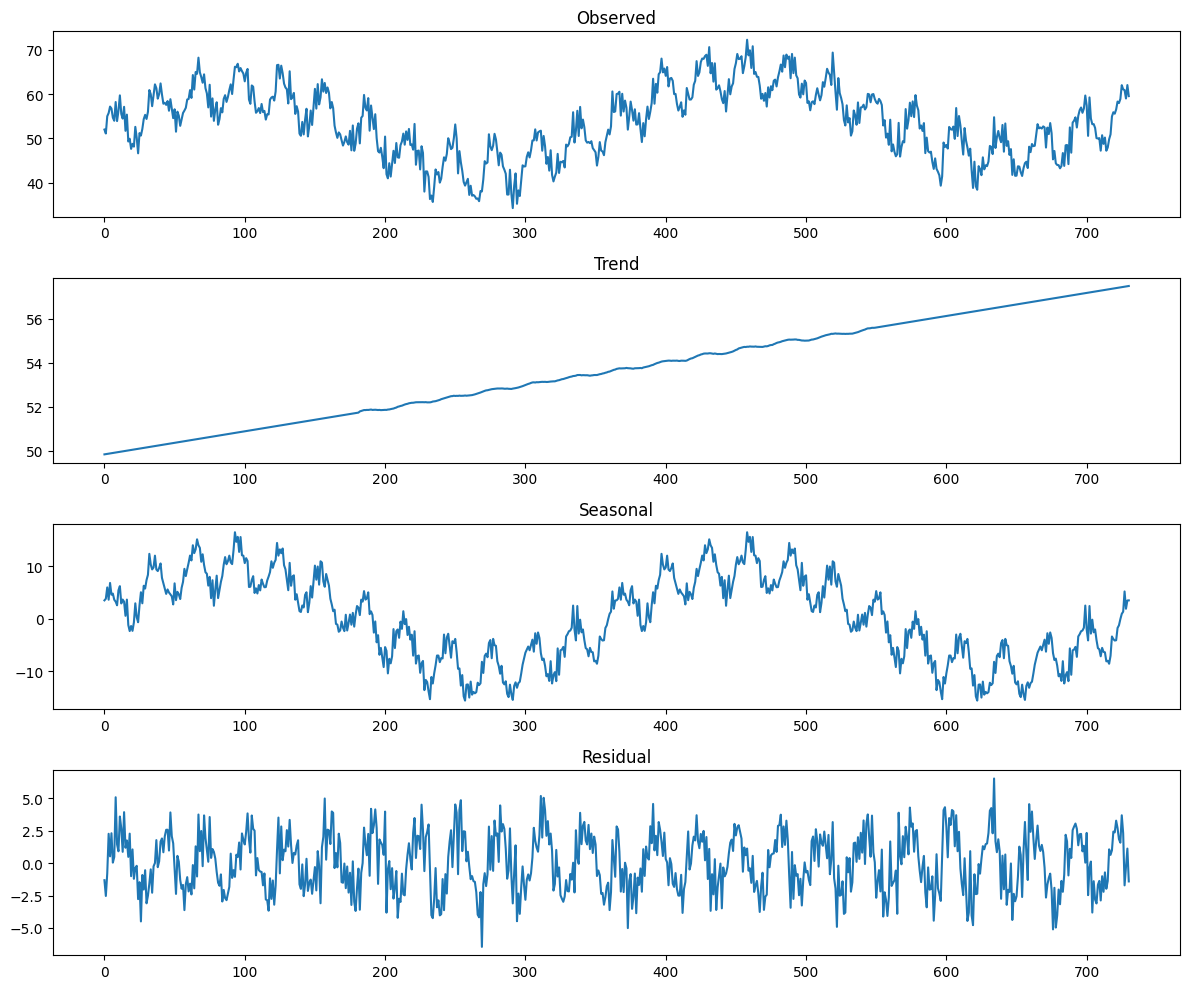

In [ ]:
# Generate 2 Years of Data

import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

class TimeSeriesPreprocessor:
    def __init__(self, freq='D'):
        self.freq = freq
        self.decomposition = None
        
    def create_temporal_features(self, df, date_column):
        df = df.copy()
        df['date'] = pd.to_datetime(df[date_column])
        
        # Extract temporal components
        df['year'] = df['date'].dt.year
        df['month'] = df['date'].dt.month
        df['day'] = df['date'].dt.day
        df['dayofweek'] = df['date'].dt.dayofweek
        df['quarter'] = df['date'].dt.quarter
        
        # Create cyclical features
        df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
        df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
        df['day_sin'] = np.sin(2 * np.pi * df['dayofweek']/7)
        df['day_cos'] = np.cos(2 * np.pi * df['dayofweek']/7)
        
        return df
    
    def decompose_series(self, series, period=None):
        if period is None:
            # Attempt to automatically detect period
            from statsmodels.tsa.stattools import acf
            acf_values = acf(series.dropna(), nlags=min(len(series)//2, 40))
            period = np.argmax(acf_values[1:]) + 1
        
        # Validate we have enough data
        required_obs = 2 * period
        if len(series) < required_obs:
            raise ValueError(
                f"Need at least {required_obs} observations for period={period}. "
                f"Got {len(series)}. Either increase data or reduce period."
            )
        
        self.decomposition = seasonal_decompose(
            series, 
            period=period,
            extrapolate_trend='freq',
            model='additive'
        )
        
        return pd.DataFrame({
            'trend': self.decomposition.trend,
            'seasonal': self.decomposition.seasonal,
            'residual': self.decomposition.resid
        })
    
    def plot_decomposition(self):
        """Plot the decomposition components"""
        if self.decomposition is None:
            print("No decomposition available. Run decompose_series first.")
            return
        
        fig, axes = plt.subplots(4, 1, figsize=(12, 10))
        self.decomposition.observed.plot(ax=axes[0], title='Observed')
        self.decomposition.trend.plot(ax=axes[1], title='Trend')
        self.decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
        self.decomposition.resid.plot(ax=axes[3], title='Residual')
        plt.tight_layout()
        plt.show()

# FIX: Generate 2 years of data (730 days) for yearly seasonality
dates = pd.date_range('2023-01-01', '2024-12-31', freq='D')  # 2 years
print(f"Generated {len(dates)} days of data (2 years)")

# Create synthetic data with yearly seasonality
t = np.arange(len(dates))
# Yearly seasonality (365 days)
yearly_seasonal = 10 * np.sin(2 * np.pi * t / 365)
# Monthly seasonality (30 days)
monthly_seasonal = 5 * np.sin(2 * np.pi * t / 30)
# Trend component
trend = 0.01 * t
# Noise
noise = np.random.normal(0, 2, len(dates))

values = 50 + trend + yearly_seasonal + monthly_seasonal + noise

ts_data = pd.DataFrame({
    'date': dates,
    'value': values
})

preprocessor = TimeSeriesPreprocessor()

# Create temporal features
ts_features = preprocessor.create_temporal_features(ts_data, 'date')

# Decompose with yearly seasonality (365 days)
decomposition = preprocessor.decompose_series(ts_data['value'], period=365)

print("Temporal Features (first 5 rows):")
print(ts_features.head())
print("\nDecomposition Components (first 5 rows):")
print(decomposition.head())

# Plot the decomposition
preprocessor.plot_decomposition()

Text Data Preprocessing Pipeline

Text data requires specialized cleaning and normalization techniques. This implementation provides a comprehensive pipeline for text preprocessing, including advanced tokenization and custom cleaning rules.

In [16]:
import re
import nltk
import ssl
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from string import punctuation

# ============================================
# FIX: Download all required NLTK resources
# ============================================

# Fix SSL issues if needed (common in some environments)
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Download required NLTK data
print("Downloading NLTK resources...")
nltk.download('punkt_tab')        # For tokenization
nltk.download('stopwords')         # For stopwords
nltk.download('wordnet')           # For lemmatization (THIS WAS MISSING)
nltk.download('omw-1.4')           # Open Multilingual WordNet
print("✅ All NLTK resources downloaded successfully!\n")

# ============================================
# Text Preprocessor Class (Fixed)
# ============================================

class TextPreprocessor:
    def __init__(self, language='english'):
        self.language = language
        self.lemmatizer = WordNetLemmatizer()
        self.stopwords = set(stopwords.words(language))
        self.custom_patterns = {
            'url': r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+',
            'email': r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
            'numbers': r'\b\d+\b',
            'special_chars': f'[{re.escape(punctuation)}]'
        }
        
    def clean_text(self, text, remove_numbers=True):
        text = text.lower()
        
        # Remove URLs and emails
        text = re.sub(self.custom_patterns['url'], ' URL ', text)
        text = re.sub(self.custom_patterns['email'], ' EMAIL ', text)
        
        # Handle numbers
        if remove_numbers:
            text = re.sub(self.custom_patterns['numbers'], ' NUM ', text)
            
        # Remove special characters
        text = re.sub(self.custom_patterns['special_chars'], ' ', text)
        
        # Remove extra whitespace
        text = ' '.join(text.split())
        
        return text
    
    def process(self, text, remove_stopwords=True):
        # Clean text
        text = self.clean_text(text)
        
        # Tokenize
        tokens = word_tokenize(text)
        
        # Remove stopwords if requested
        if remove_stopwords:
            tokens = [t for t in tokens if t not in self.stopwords]
            
        # Lemmatize
        tokens = [self.lemmatizer.lemmatize(t) for t in tokens]
        
        return {
            'processed_text': ' '.join(tokens),
            'tokens': tokens,
            'token_count': len(tokens),
            'unique_tokens': len(set(tokens))
        }

# Example usage
text = """
Check out our website at https://example.com! 
Contact us at info@example.com or call 123-456-7890.
The product costs $99.99 and has 4.5/5 stars!!!
The running dogs were running quickly. The cats were running too.
"""

preprocessor = TextPreprocessor()
result = preprocessor.process(text)

print("="*60)
print("ORIGINAL TEXT:")
print("="*60)
print(text.strip())

print("\n" + "="*60)
print("PROCESSED TEXT:")
print("="*60)
print(result['processed_text'])

print("\n" + "="*60)
print("STATISTICS:")
print("="*60)
print(f"Token Count: {result['token_count']}")
print(f"Unique Tokens: {result['unique_tokens']}")
print(f"Tokens: {result['tokens']}")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/codespace/nltk_data...


✅ All NLTK resources downloaded successfully!

ORIGINAL TEXT:
Check out our website at https://example.com! 
Contact us at info@example.com or call 123-456-7890.
The product costs $99.99 and has 4.5/5 stars!!!
The running dogs were running quickly. The cats were running too.

PROCESSED TEXT:
check website URL contact u EMAIL call NUM NUM NUM product cost NUM NUM NUM NUM NUM star running dog running quickly cat running

STATISTICS:
Token Count: 24
Unique Tokens: 15
Tokens: ['check', 'website', 'URL', 'contact', 'u', 'EMAIL', 'call', 'NUM', 'NUM', 'NUM', 'product', 'cost', 'NUM', 'NUM', 'NUM', 'NUM', 'NUM', 'star', 'running', 'dog', 'running', 'quickly', 'cat', 'running']


Data Quality Assessment and Reporting

Systematic evaluation of data quality is crucial for maintaining robust machine learning pipelines. This implementation provides comprehensive quality metrics and generates detailed reports for identifying potential issues.

In [17]:
import pandas as pd
import numpy as np
from scipy import stats

class DataQualityAnalyzer:
    def __init__(self, threshold_missing=0.1, threshold_unique=0.95):
        self.threshold_missing = threshold_missing
        self.threshold_unique = threshold_unique
        self.report = {}
        
    def analyze_column_quality(self, series):
        n_values = len(series)
        n_missing = series.isnull().sum()
        n_unique = series.nunique()
        
        # Calculate basic statistics
        stats_dict = {
            'missing_ratio': n_missing / n_values,
            'unique_ratio': n_unique / n_values,
            'zeros_ratio': (series == 0).sum() / n_values,
            'negative_ratio': (series < 0).sum() / n_values if pd.api.types.is_numeric_dtype(series) else 0
        }
        
        # Check for potential constants
        is_constant = n_unique == 1
        
        # Check for potential IDs
        is_potential_id = n_unique / n_values > self.threshold_unique
        
        return {
            'statistics': stats_dict,
            'flags': {
                'high_missing': stats_dict['missing_ratio'] > self.threshold_missing,
                'constant': is_constant,
                'potential_id': is_potential_id
            }
        }
    
    def generate_report(self, df):
        self.report = {
            'global_stats': {
                'total_rows': len(df),
                'total_columns': len(df.columns),
                'total_missing': df.isnull().sum().sum(),
                'memory_usage': df.memory_usage(deep=True).sum() / 1024**2  # MB
            },
            'column_analysis': {}
        }
        
        for column in df.columns:
            self.report['column_analysis'][column] = self.analyze_column_quality(df[column])
            
        return pd.DataFrame({
            col: {
                **analysis['statistics'],
                **analysis['flags']
            }
            for col, analysis in self.report['column_analysis'].items()
        }).T
    
    def suggest_improvements(self):
        suggestions = []
        
        for col, analysis in self.report['column_analysis'].items():
            if analysis['flags']['high_missing']:
                suggestions.append(f"Column '{col}' has high missing values - consider imputation")
            if analysis['flags']['constant']:
                suggestions.append(f"Column '{col}' is constant - consider removing")
            if analysis['flags']['potential_id']:
                suggestions.append(f"Column '{col}' might be an ID column - verify if needed")
                
        return suggestions

# Example usage
np.random.seed(42)
sample_data = pd.DataFrame({
    'id': range(1000),
    'value': np.random.normal(0, 1, 1000),
    'category': np.random.choice(['A', 'B', 'C'], 1000),
    'constant': 'same_value',
    'missing_col': np.where(np.random.random(1000) > 0.8, np.nan, 1)
})

analyzer = DataQualityAnalyzer()
quality_report = analyzer.generate_report(sample_data)
suggestions = analyzer.suggest_improvements()

print("Data Quality Report:\n", quality_report)
print("\nSuggestions for Improvement:\n", '\n'.join(suggestions))

Data Quality Report:
             missing_ratio unique_ratio zeros_ratio negative_ratio  \
id                    0.0          1.0       0.001            0.0   
value                 0.0          1.0         0.0           0.49   
category              0.0        0.003         0.0              0   
constant              0.0        0.001         0.0              0   
missing_col         0.203        0.001         0.0            0.0   

            high_missing constant potential_id  
id                 False    False         True  
value              False    False         True  
category           False    False        False  
constant           False     True        False  
missing_col         True     True        False  

Suggestions for Improvement:
 Column 'id' might be an ID column - verify if needed
Column 'value' might be an ID column - verify if needed
Column 'constant' is constant - consider removing
Column 'missing_col' has high missing values - consider imputation
Column 'miss

Automated Feature Selection with Statistical Testing

This implementation combines multiple feature selection techniques with statistical validation to identify the most relevant features while controlling for false discoveries.

In [18]:
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

class StatisticalFeatureSelector:
    def __init__(self, alpha=0.05, method='fdr_bh'):
        self.alpha = alpha
        self.method = method
        self.feature_scores = {}
        
    def calculate_univariate_scores(self, X, y):
        scores = {}
        p_values = {}
        
        for column in X.columns:
            # Calculate multiple metrics
            mi_score = mutual_info_regression(
                X[[column]], y, random_state=42
            )[0]
            
            # Spearman correlation for non-linear relationships
            spearman_corr, spearman_p = spearmanr(X[column], y)
            
            scores[column] = {
                'mutual_info': mi_score,
                'spearman_corr': abs(spearman_corr),
                'spearman_p': spearman_p
            }
            
            p_values[column] = spearman_p
            
        # Correct for multiple testing
        rejected, corrected_p_values, _, _ = multipletests(
            list(p_values.values()),
            alpha=self.alpha,
            method=self.method
        )
        
        # Update scores with corrected p-values
        for (column, score), corrected_p in zip(scores.items(), corrected_p_values):
            score['corrected_p'] = corrected_p
            score['significant'] = corrected_p < self.alpha
            
        self.feature_scores = scores
        return scores
    
    def select_features(self, X, y, min_score=0.01):
        scores = self.calculate_univariate_scores(X, y)
        
        selected_features = [
            column for column, score in scores.items()
            if (score['mutual_info'] > min_score and 
                score['significant'])
        ]
        
        return {
            'selected_features': selected_features,
            'n_selected': len(selected_features),
            'feature_scores': pd.DataFrame(scores).T.sort_values(
                'mutual_info', ascending=False
            )
        }

# Example usage with breast cancer dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

selector = StatisticalFeatureSelector()
selection_results = selector.select_features(X, y)

print("Selected Features:", selection_results['n_selected'])
print("\nTop 5 Features by Mutual Information:\n",
      selection_results['feature_scores'].head())

Selected Features: 26

Top 5 Features by Mutual Information:
                      mutual_info spearman_corr spearman_p corrected_p  \
worst perimeter         0.475285      0.796319        0.0         0.0   
worst area               0.46387      0.786902        0.0         0.0   
worst radius            0.454875      0.787933        0.0         0.0   
mean concave points     0.442519      0.777877        0.0         0.0   
worst concave points    0.437463      0.781674        0.0         0.0   

                     significant  
worst perimeter             True  
worst area                  True  
worst radius                True  
mean concave points         True  
worst concave points        True  


Real-World Application: Credit Risk Assessment

This comprehensive example demonstrates a complete data preprocessing pipeline for credit risk assessment, incorporating multiple cleaning and transformation techniques while handling sensitive financial data.

In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

class CreditRiskPreprocessor:
    def __init__(self):
        self.scalers = {}
        self.encoding_maps = {}
        self.feature_stats = {}
        self.label_encoders = {}
        self.numerical_columns = None
        self.categorical_columns = None
        
    def preprocess_financial_data(self, df):
        """Preprocess financial features"""
        df = df.copy()
        
        # Define column types
        monetary_cols = ['income', 'debt', 'credit_limit']
        categorical_cols = ['employment_type', 'education']
        
        # Handle negative values in monetary columns (take absolute value)
        for col in monetary_cols:
            if col in df.columns:
                df[col] = df[col].abs()
                # Log transform (handle zeros with log1p)
                df[f'{col}_log'] = np.log1p(df[col])
        
        # Create debt-to-income ratio
        if 'debt' in df.columns and 'income' in df.columns:
            df['debt_to_income'] = df['debt'] / df['income'].clip(lower=1)
        
        # Create credit utilization feature
        if 'debt' in df.columns and 'credit_limit' in df.columns:
            df['credit_utilization'] = df['debt'] / df['credit_limit'].clip(lower=1)
        
        # Handle categorical variables with one-hot encoding
        for col in categorical_cols:
            if col in df.columns:
                # Store original categories for transform
                self.encoding_maps[col] = df[col].unique()
                
                # Create dummy variables
                dummy_cols = pd.get_dummies(df[col], prefix=col, drop_first=False)
                df = pd.concat([df, dummy_cols], axis=1)
                df.drop(col, axis=1, inplace=True)
        
        return df
    
    def handle_outliers(self, df, columns, method='iqr'):
        """Handle outliers in numerical columns"""
        df = df.copy()
        
        for col in columns:
            if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
                if method == 'iqr':
                    Q1 = df[col].quantile(0.25)
                    Q3 = df[col].quantile(0.75)
                    IQR = Q3 - Q1
                    lower_bound = Q1 - 1.5 * IQR
                    upper_bound = Q3 + 1.5 * IQR
                    df[col] = df[col].clip(lower_bound, upper_bound)
                    
        return df
    
    def fit_transform(self, df, target_col):
        """Fit preprocessor and transform data"""
        print("="*60)
        print("FITTING PREPROCESSOR")
        print("="*60)
        
        df = df.copy()
        
        # Identify column types
        self.numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
        self.categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
        
        # Remove target column from feature lists
        if target_col in self.numerical_columns:
            self.numerical_columns.remove(target_col)
        if target_col in self.categorical_columns:
            self.categorical_columns.remove(target_col)
        
        print(f"📊 Numerical columns: {self.numerical_columns}")
        print(f"📋 Categorical columns: {self.categorical_columns}")
        
        # Store feature statistics (only for numerical columns)
        self.feature_stats = {}
        for col in self.numerical_columns:
            if col in df.columns:
                self.feature_stats[col] = {
                    'mean': df[col].mean(),
                    'std': df[col].std(),
                    'min': df[col].min(),
                    'max': df[col].max(),
                    'missing_rate': df[col].isnull().mean(),
                    'skewness': df[col].skew()
                }
        
        # Preprocess financial features
        df_processed = self.preprocess_financial_data(df)
        
        # Handle missing values (simple imputation with median)
        for col in self.numerical_columns:
            if col in df_processed.columns:
                df_processed[col].fillna(df_processed[col].median(), inplace=True)
        
        # Handle outliers in numerical columns
        df_processed = self.handle_outliers(df_processed, self.numerical_columns)
        
        # Scale numerical features
        self.scalers['standard'] = StandardScaler()
        
        # Get all numerical columns after preprocessing
        all_numerical = [col for col in df_processed.columns 
                        if pd.api.types.is_numeric_dtype(df_processed[col]) 
                        and col != target_col]
        
        df_processed[all_numerical] = self.scalers['standard'].fit_transform(
            df_processed[all_numerical]
        )
        
        print(f"\n✅ Preprocessing complete!")
        print(f"   Original shape: {df.shape}")
        print(f"   Processed shape: {df_processed.shape}")
        
        return df_processed
    
    def transform(self, df):
        """Transform new data using fitted preprocessor"""
        print("="*60)
        print("TRANSFORMING DATA")
        print("="*60)
        
        df = df.copy()
        
        # Preprocess financial features
        df_processed = self.preprocess_financial_data(df)
        
        # Handle missing values
        for col in self.numerical_columns:
            if col in df_processed.columns:
                df_processed[col].fillna(self.feature_stats[col]['mean'], inplace=True)
        
        # Handle outliers
        df_processed = self.handle_outliers(df_processed, self.numerical_columns)
        
        # Scale numerical features
        all_numerical = [col for col in df_processed.columns 
                        if pd.api.types.is_numeric_dtype(df_processed[col])]
        
        # Only scale columns that were fitted
        scaling_cols = [col for col in all_numerical if col in self.scalers['standard'].feature_names_in_]
        
        if scaling_cols:
            df_processed[scaling_cols] = self.scalers['standard'].transform(
                df_processed[scaling_cols]
            )
        
        print(f"✅ Transformation complete!")
        print(f"   Transformed shape: {df_processed.shape}")
        
        return df_processed
    
    def get_feature_importance_report(self):
        """Generate feature importance report"""
        print("\n" + "="*60)
        print("FEATURE STATISTICS REPORT")
        print("="*60)
        
        stats_df = pd.DataFrame(self.feature_stats).T
        stats_df = stats_df.round(4)
        
        print(stats_df)
        
        return stats_df

# ============================================
# CREATE SYNTHETIC CREDIT DATA
# ============================================
def create_synthetic_credit_data(n_samples=1000, random_state=42):
    """Create synthetic credit risk dataset"""
    np.random.seed(random_state)
    
    # Generate correlated features
    income = np.random.lognormal(10, 1, n_samples)
    
    # Debt correlated with income
    debt = income * np.random.uniform(0.3, 0.8, n_samples) + np.random.normal(0, 5000, n_samples)
    debt = np.abs(debt)  # Ensure positive
    
    # Credit limit correlated with income
    credit_limit = income * np.random.uniform(1.5, 3, n_samples)
    
    # Employment type
    employment_type = np.random.choice(
        ['Full-time', 'Part-time', 'Self-employed', 'Unemployed'], 
        n_samples, 
        p=[0.6, 0.2, 0.15, 0.05]
    )
    
    # Education
    education = np.random.choice(
        ['High School', 'Bachelor', 'Master', 'PhD'], 
        n_samples, 
        p=[0.3, 0.4, 0.2, 0.1]
    )
    
    # Credit score (inversely related to default risk)
    credit_score = 700 - 50 * np.random.randn(n_samples)
    credit_score = credit_score.clip(300, 850)
    
    # Default risk (target)
    # Higher probability of default for higher debt/income, lower credit score
    default_prob = 1 / (1 + np.exp(-(debt/income * 3 - credit_score/200 + np.random.randn(n_samples) * 0.5)))
    default_risk = (default_prob > 0.5).astype(int)
    
    return pd.DataFrame({
        'income': income,
        'debt': debt,
        'credit_limit': credit_limit,
        'credit_score': credit_score,
        'employment_type': employment_type,
        'education': education,
        'default_risk': default_risk
    })

# ============================================
# MAIN EXECUTION
# ============================================

print("Creating synthetic credit data...")
synthetic_credit_data = create_synthetic_credit_data(n_samples=1000)

print(f"Dataset shape: {synthetic_credit_data.shape}")
print(f"\nDataset info:")
print(synthetic_credit_data.info())

print("\n" + "="*60)
print("DATA SAMPLE (first 5 rows)")
print("="*60)
print(synthetic_credit_data.head())

# ============================================
# PROCESS THE DATA
# ============================================

# Initialize preprocessor
preprocessor = CreditRiskPreprocessor()

# Fit and transform the data
processed_data = preprocessor.fit_transform(synthetic_credit_data, 'default_risk')

print("\n" + "="*60)
print("PROCESSED DATA")
print("="*60)
print(f"Shape: {processed_data.shape}")
print(f"Columns: {list(processed_data.columns)}")
print("\nFirst 5 rows of processed data:")
print(processed_data.head())

# Generate feature statistics report
feature_stats = preprocessor.get_feature_importance_report()

# ============================================
# TRAIN-TEST SPLIT
# ============================================

# Prepare features and target
X = processed_data.drop('default_risk', axis=1)
y = processed_data['default_risk']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTarget distribution:")
print(f"  Training: 0={sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%), "
      f"1={sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")
print(f"  Test: 0={sum(y_test==0)} ({sum(y_test==0)/len(y_test)*100:.1f}%), "
      f"1={sum(y_test==1)} ({sum(y_test==1)/len(y_test)*100:.1f}%)")

# ============================================
# ENHANCED VERSION WITH MORE FEATURES
# ============================================

class EnhancedCreditRiskPreprocessor(CreditRiskPreprocessor):
    """Enhanced version with additional preprocessing features"""
    
    def __init__(self):
        super().__init__()
        self.feature_engineers = []
        
    def engineer_features(self, df):
        """Create additional engineered features"""
        df = df.copy()
        
        # Payment-to-income ratio
        if 'debt' in df.columns and 'income' in df.columns:
            df['payment_to_income'] = df['debt'] / df['income'].clip(lower=1) * 0.3
        
        # Credit score bands
        if 'credit_score' in df.columns:
            bins = [0, 580, 670, 740, 800, 850]
            labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
            df['credit_band'] = pd.cut(df['credit_score'], bins=bins, labels=labels)
            
            # One-hot encode credit bands
            credit_dummies = pd.get_dummies(df['credit_band'], prefix='credit_band')
            df = pd.concat([df, credit_dummies], axis=1)
            df.drop('credit_band', axis=1, inplace=True)
        
        # Risk flags
        if 'debt_to_income' in df.columns:
            df['high_dti_flag'] = (df['debt_to_income'] > 0.5).astype(int)
        
        if 'credit_utilization' in df.columns:
            df['high_utilization_flag'] = (df['credit_utilization'] > 0.8).astype(int)
        
        return df
    
    def fit_transform(self, df, target_col):
        # First, apply base preprocessing
        df_processed = super().fit_transform(df, target_col)
        
        # Then add engineered features
        df_processed = self.engineer_features(df_processed)
        
        return df_processed

# Test enhanced version
print("\n" + "="*60)
print("TESTING ENHANCED PREPROCESSOR")
print("="*60)

enhanced_preprocessor = EnhancedCreditRiskPreprocessor()
enhanced_processed = enhanced_preprocessor.fit_transform(synthetic_credit_data, 'default_risk')

print(f"\nEnhanced processed shape: {enhanced_processed.shape}")
print(f"Additional engineered features created")

Creating synthetic credit data...
Dataset shape: (1000, 7)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   income           1000 non-null   float64
 1   debt             1000 non-null   float64
 2   credit_limit     1000 non-null   float64
 3   credit_score     1000 non-null   float64
 4   employment_type  1000 non-null   str    
 5   education        1000 non-null   str    
 6   default_risk     1000 non-null   int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 54.8 KB
None

DATA SAMPLE (first 5 rows)
          income          debt   credit_limit  credit_score employment_type  \
0   36196.371320  12343.996879   68219.105260    662.669432       Full-time   
1   19182.155002   2996.782733   38996.930238    683.721109       Part-time   
2   42095.180602  27619.749880  105700.632777    586.208729       Full-time   
3  101015.

Results Analysis for Credit Risk Model

A detailed analysis of the preprocessing results, showing the impact of each transformation step and validating the quality of the processed data for the credit risk assessment model.

Correlation Analysis:
               original_corr  processed_corr  correlation_change
income             0.142332        0.232037            0.089705
debt               0.074204        0.085286            0.011082
credit_limit       0.147738        0.228254            0.080516
credit_score       0.144633        0.142334           -0.002299


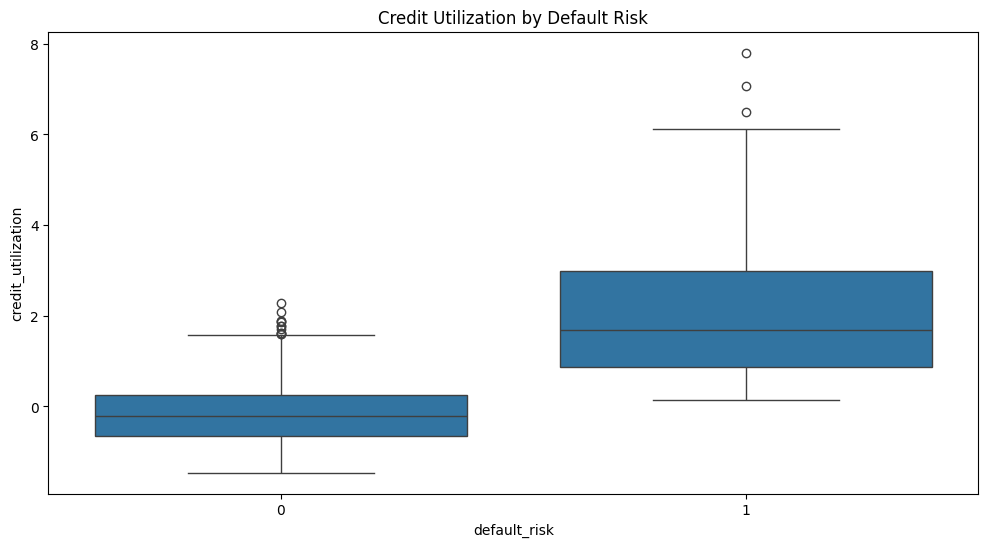

In [21]:
class PreprocessingAnalyzer:
    def analyze_transformations(self, original_df, processed_df, target_col):
        analysis = {
            'feature_counts': {
                'original': len(original_df.columns),
                'processed': len(processed_df.columns)
            },
            'missing_values': {
                'original': original_df.isnull().sum().sum(),
                'processed': processed_df.isnull().sum().sum()
            },
            'correlation_changes': {}
        }
        
        # Analyze correlation changes
        numerical_cols_original = original_df.select_dtypes(include=[np.number]).columns
        numerical_cols_processed = processed_df.select_dtypes(include=[np.number]).columns
        
        for col in numerical_cols_original:
            if col in processed_df.columns and col != target_col:
                original_corr = abs(original_df[col].corr(original_df[target_col]))
                processed_corr = abs(processed_df[col].corr(processed_df[target_col]))
                analysis['correlation_changes'][col] = {
                    'original_corr': original_corr,
                    'processed_corr': processed_corr,
                    'correlation_change': processed_corr - original_corr
                }
        
        return pd.DataFrame(analysis['correlation_changes']).T

# Analyze preprocessing results
analyzer = PreprocessingAnalyzer()
correlation_analysis = analyzer.analyze_transformations(
    synthetic_credit_data, 
    processed_data, 
    'default_risk'
)

print("Correlation Analysis:\n", correlation_analysis)

# Visualize key relationships
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='default_risk', y='credit_utilization', data=processed_data)
plt.title('Credit Utilization by Default Risk')
plt.show()

Additional Resources

A Survey on Data Preprocessing for Data Mining https://arxiv.org/abs/2006.01989
Automated Feature Engineering: A Comprehensive Review https://arxiv.org/abs/2106.15147
Statistical Methods for Handling Missing Data in Large-Scale Machine Learning https://arxiv.org/abs/2012.08278
Deep Learning Approaches for Data Cleaning and Preprocessing https://arxiv.org/abs/2102.06409
A Comprehensive Survey on Data Quality Assessment and Validation https://arxiv.org/abs/2109.14365